# 📊 Unemployment Analysis in India
### Task 2 – Data Science Project

Unemployment is measured by the **unemployment rate** — the number of people who are unemployed as a percentage of the total labour force.  
During **Covid-19**, India witnessed a sharp spike in unemployment. This notebook provides a complete exploratory and visual analysis of that trend.

**Datasets used:**
- `Unemployment_in_India.csv` — Monthly state-wise data (May 2019 onwards)
- `Unemployment_Rate_upto_11_2020.csv` — Jan 2020 – Nov 2020 with geo-coordinates


---
## 1. Import Libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize']=(14,6)
plt.rcParams['figure.dpi']=120

print('All libraries imported successfully')

All libraries imported successfully


---
## 2. Load & Inspect Dataset

In [11]:
#Dataset-1: Broader Historical Data
df1=pd.read_csv(r"C:\Users\Dell\Desktop\INTERNSHIPS\Oasis_Info_Byte(DS)\Task_2_Unemployment_Analysis\Dataset\Unemployment in India.csv")
df1.columns=df1.columns.str.strip()

#Dataset-2: Jan-Nov 2020 with geo info
df2=pd.read_csv(r"C:\Users\Dell\Desktop\INTERNSHIPS\Oasis_Info_Byte(DS)\Task_2_Unemployment_Analysis\Dataset\Unemployment_Rate_upto_11_2020.csv")
df2.columns=df2.columns.str.strip()

print("===== Dataset:1 shape: ", df1.shape)
df1.head()

===== Dataset:1 shape:  (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [12]:
print("===== Dataset-2 shape: ",df2.shape)
df2.head()

===== Dataset-2 shape:  (267, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


---
## 3.Data cleaning and preprocessing

In [14]:
# ── Dataset 1 ──
df1['Date'] = pd.to_datetime(df1['Date'].str.strip(), format='%d-%m-%Y')
df1['Region'] = df1['Region'].str.strip()
df1['Area'] = df1['Area'].str.strip()

# Rename columns for convenience
df1.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
}, inplace=True)

print('Dataset 1 – Missing values:')
print(df1.isnull().sum())
df1.dropna(inplace=True)
print('\nDataset 1 dtypes:')
df1.dtypes

Dataset 1 – Missing values:
Region                       28
Date                         28
Frequency                    28
Unemployment_Rate            28
Employed                     28
Labour_Participation_Rate    28
Area                         28
dtype: int64

Dataset 1 dtypes:


Region                                  str
Date                         datetime64[us]
Frequency                               str
Unemployment_Rate                   float64
Employed                            float64
Labour_Participation_Rate           float64
Area                                    str
dtype: object

In [15]:
# ── Dataset 2 ──
df2['Date'] = pd.to_datetime(df2['Date'].str.strip(), format='%d-%m-%Y')
df2['Region'] = df2['Region'].str.strip()

# Keep the geographic region column (South/North etc.) — rename to avoid clash
col_list = list(df2.columns)
# There are two 'Region' cols after strip; handle by position
df2.columns = ['State', 'Date', 'Frequency', 'Unemployment_Rate',
                'Employed', 'Labour_Participation_Rate', 'Region', 'Longitude', 'Latitude']

df2['State'] = df2['State'].str.strip()
df2['Region'] = df2['Region'].str.strip()

print('Dataset 2 – Missing values:')
print(df2.isnull().sum())
df2.dropna(inplace=True)
print('\nCleaned!')

Dataset 2 – Missing values:
State                        0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Region                       0
Longitude                    0
Latitude                     0
dtype: int64

Cleaned!


In [16]:
# Add Year and Month column to dataset-1

df1['Year']=df1['Date'].dt.year
df1['Month']=df1['Date'].dt.month_name()

#Add month column to datset2:
df2['Month_num']=df2['Date'].dt.month
df2['Month']=df2['Date'].dt.month_name()


print('Preprocessing complete ✅')
print('Date range (df1):', df1['Date'].min().date(), '→', df1['Date'].max().date())
print('Date range (df2):', df2['Date'].min().date(), '→', df2['Date'].max().date())

Preprocessing complete ✅
Date range (df1): 2019-05-31 → 2020-06-30
Date range (df2): 2020-01-31 → 2020-10-31


---
## 4. Descriptive Statistics

In [17]:
print('=== Dataset 1 – Summary Statistics ===')
df1[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].describe().round(2)




=== Dataset 1 – Summary Statistics ===


,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740.00,740.00,740.00
mean,11.79,7204460.03,42.63
std,10.72,8087988.43,8.11
min,0.00,49420.00,13.33
25%,4.66,1190404.50,38.06
50%,8.35,4744178.50,41.16
75%,15.89,11275489.50,45.50
max,76.74,45777509.00,72.57


In [18]:
print('==== Dataset2 summary statistics: ===')
df2[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].describe().round(2)

==== Dataset2 summary statistics: ===


,Unemployment_Rate,Employed,Labour_Participation_Rate
count,267.00,267.00,267.00
mean,12.24,13962105.72,41.68
std,10.80,13366318.36,7.85
min,0.50,117542.00,16.77
25%,4.84,2838930.50,37.26
50%,9.65,9732417.00,40.39
75%,16.76,21878686.00,44.06
max,75.85,59433759.00,69.69


---
# Overall unemployment rate over tuime

In [19]:
monthly_avg=df1.groupby('Date')['Unemployment_Rate'].mean().reset_index()
fig=px.line(
    monthly_avg, x='Date', y='Unemployment_Rate',
    title='Avg. monthly unemployment rate in India',
    labels={'Unemployment_Rate':'Unemployment Rate (%)','Date':'Month'},
    template='plotly_dark'
)
fig.add_vrect(x0='2020-03-01', x1='2020-06-30',
              annotation_text='COVID-19 Lockdown', annotation_position='top left',
              fillcolor='red', opacity=0.15, line_width=0)
fig.update_traces(line=dict(width=2.5, color='#FFA500'))
fig.update_layout(title_font_size=18)
fig.show()

---
## 6. Rural VS Urban unemployment

In [20]:
area_monthly=df1.groupby(['Date','Area'])['Unemployment_Rate'].mean().reset_index()


fig = px.line(
    area_monthly, x='Date', y='Unemployment_Rate', color='Area',
    title=' Rural vs Urban Unemployment Rate Over Time',
    labels={'Unemployment_Rate': 'Unemployment Rate (%)', 'Date': 'Month'},
    template='plotly_dark',
    color_discrete_map={'Rural': '#FFA500', 'Urban': '#00BFFF'}
)
fig.add_vrect(x0='2020-03-01', x1='2020-06-30',
              annotation_text='Lockdown', fillcolor='red', opacity=0.12, line_width=0)
fig.update_traces(line=dict(width=2))
fig.show()

---
## 7. State-wise avg. unemployment rate

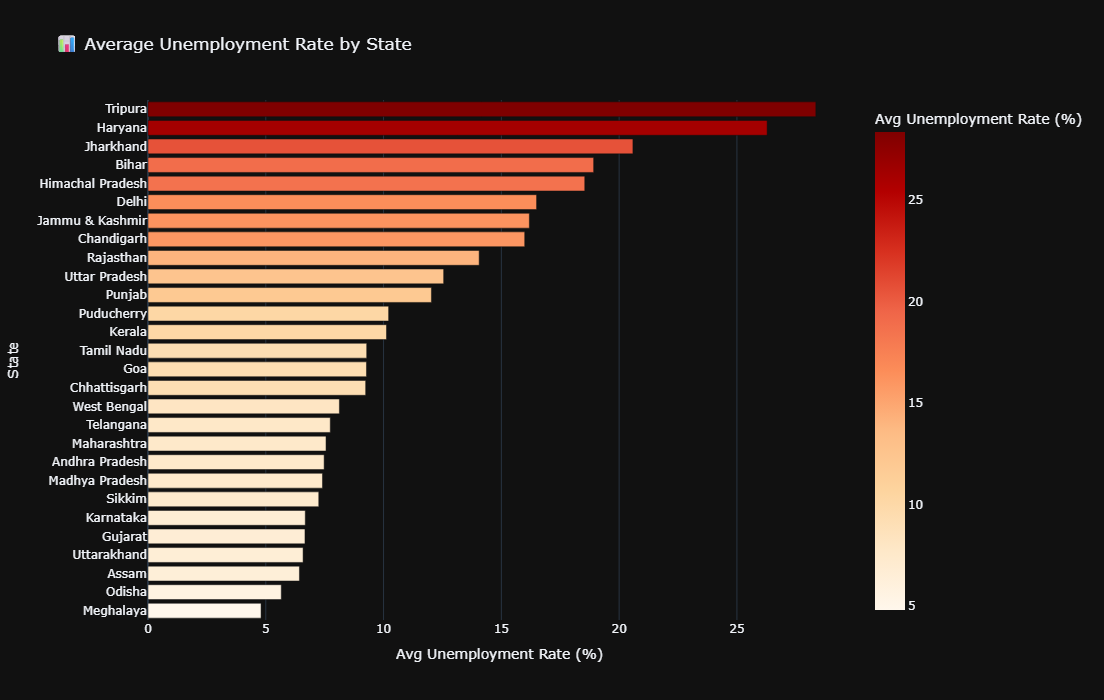

In [21]:
state_avg = df1.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False).reset_index()

fig = px.bar(
    state_avg, x='Unemployment_Rate', y='Region', orientation='h',
    title='📊 Average Unemployment Rate by State',
    labels={'Unemployment_Rate': 'Avg Unemployment Rate (%)', 'Region': 'State'},
    color='Unemployment_Rate',
    color_continuous_scale='OrRd',
    template='plotly_dark'
)
fig.update_layout(height=700, yaxis={'categoryorder': 'total ascending'})
fig.show()

---
## 8. Top5 and bottom5 states by unemployment

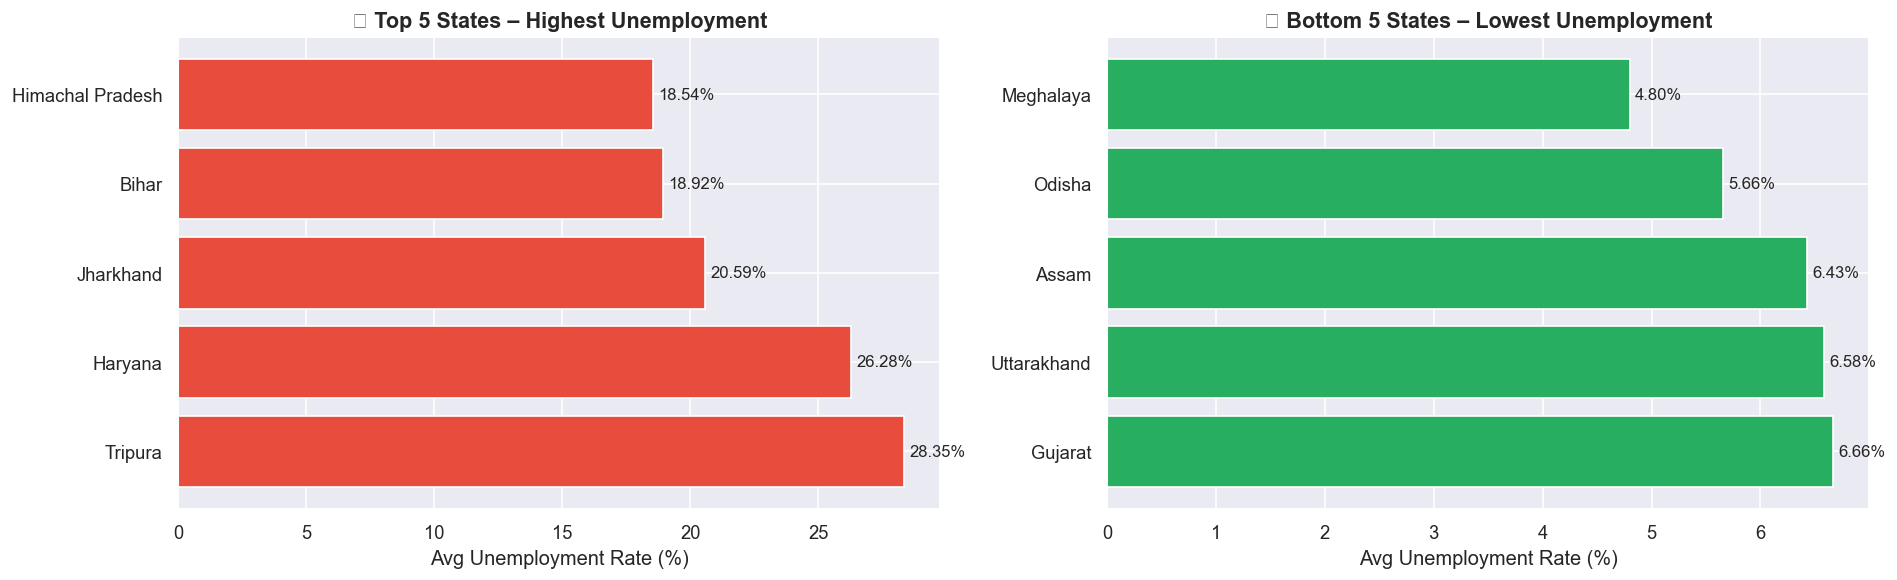

In [22]:
top5    = state_avg.head(5)
bottom5 = state_avg.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 5 – Highest
axes[0].barh(top5['Region'], top5['Unemployment_Rate'], color='#E74C3C')
axes[0].set_title('🔴 Top 5 States – Highest Unemployment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Avg Unemployment Rate (%)')
for i, v in enumerate(top5['Unemployment_Rate']):
    axes[0].text(v + 0.2, i, f'{v:.2f}%', va='center', fontsize=10)

# Bottom 5 – Lowest
axes[1].barh(bottom5['Region'], bottom5['Unemployment_Rate'], color='#27AE60')
axes[1].set_title('🟢 Bottom 5 States – Lowest Unemployment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Unemployment Rate (%)')
for i, v in enumerate(bottom5['Unemployment_Rate']):
    axes[1].text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Covid-19 Pre vs Post Lockdown effect

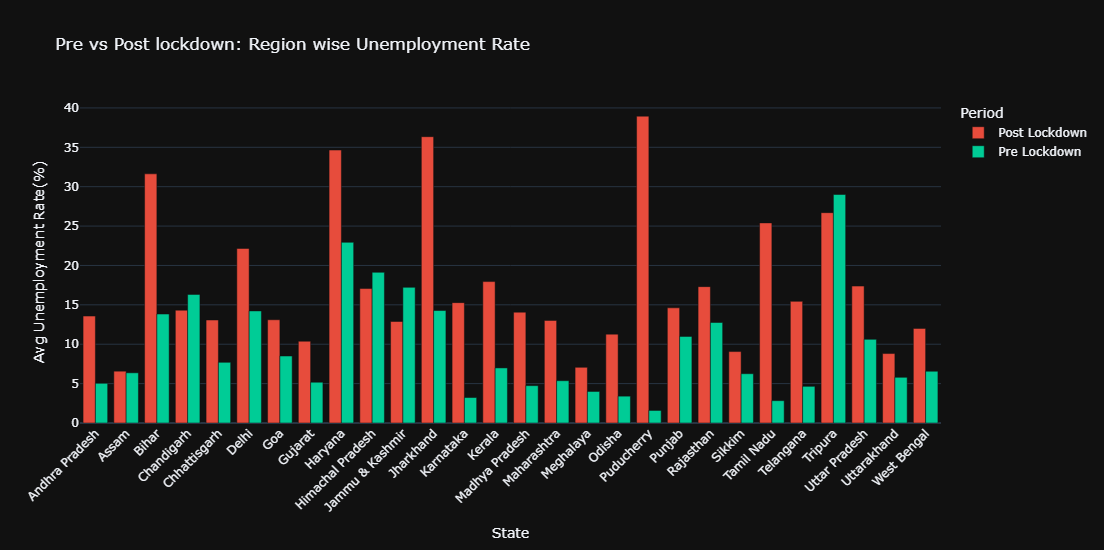

In [25]:
#Define lockdown cutoff
lockdown_date= pd.Timestamp('2020-03-24')

df1['Period']=df1['Date'].apply(lambda x:'Post Lockdown' if x>=lockdown_date else 'Pre Lockdown')

period_state=df1.groupby(['Region','Period'])['Unemployment_Rate'].mean().reset_index()

fig=px.bar(
    period_state, x='Region', y='Unemployment_Rate', color='Period',
    barmode='group',
    title='Pre vs Post lockdown: Region wise Unemployment Rate',
    labels={'Unemployment_Rate':'Avg Unemployment Rate(%)','Region':'State'},
    color_discrete_map={'Pre lockdown':'#3498DB','Post Lockdown':'#E74C3C'},
    template='plotly_dark'
)
fig.update_layout(xaxis_tickangle=-45, height=550)
fig.show()

In [26]:
#National summary
national_period=df1.groupby('Period')['Unemployment_Rate'].mean()
print('============ National Avg Unemployment Rate =============')
print(national_period.round(2))
change=national_period['Post Lockdown']-national_period['Pre Lockdown']
print(f'\n Increase due to lockdown: {change:.2f} percentage points')

============ National Avg Unemployment Rate =============
Period
Post Lockdown    17.77
Pre Lockdown      9.51
Name: Unemployment_Rate, dtype: float64

 Increase due to lockdown: 8.26 percentage points


## 10. Monthly Unemployment Distribution (Box Plot)


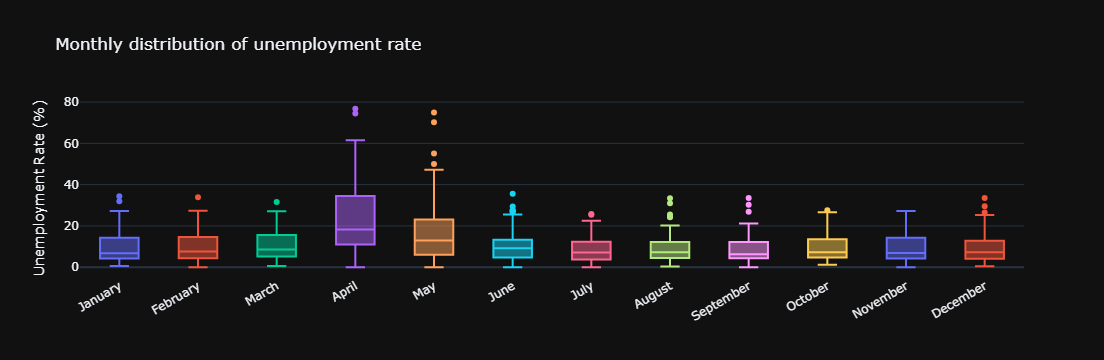

In [29]:
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']

df1['Month']=pd.Categorical(df1['Month'],categories=month_order,ordered=True)
df1_sorted=df1.sort_values('Month')

fig=px.box(
    df1_sorted, x='Month', y='Unemployment_Rate',
    title='Monthly distribution of unemployment rate',
    labels={'Unemployment_Rate':'Unemployment Rate (%)','Month':''},
    color='Month',
    template='plotly_dark'
)
fig.update_layout(showlegend=False, xaxis_tickangle=-30)
fig.show()

## 11. HeatMap - State x Month Unemployment

TypeError: xlabel() missing 1 required positional argument: 'xlabel'

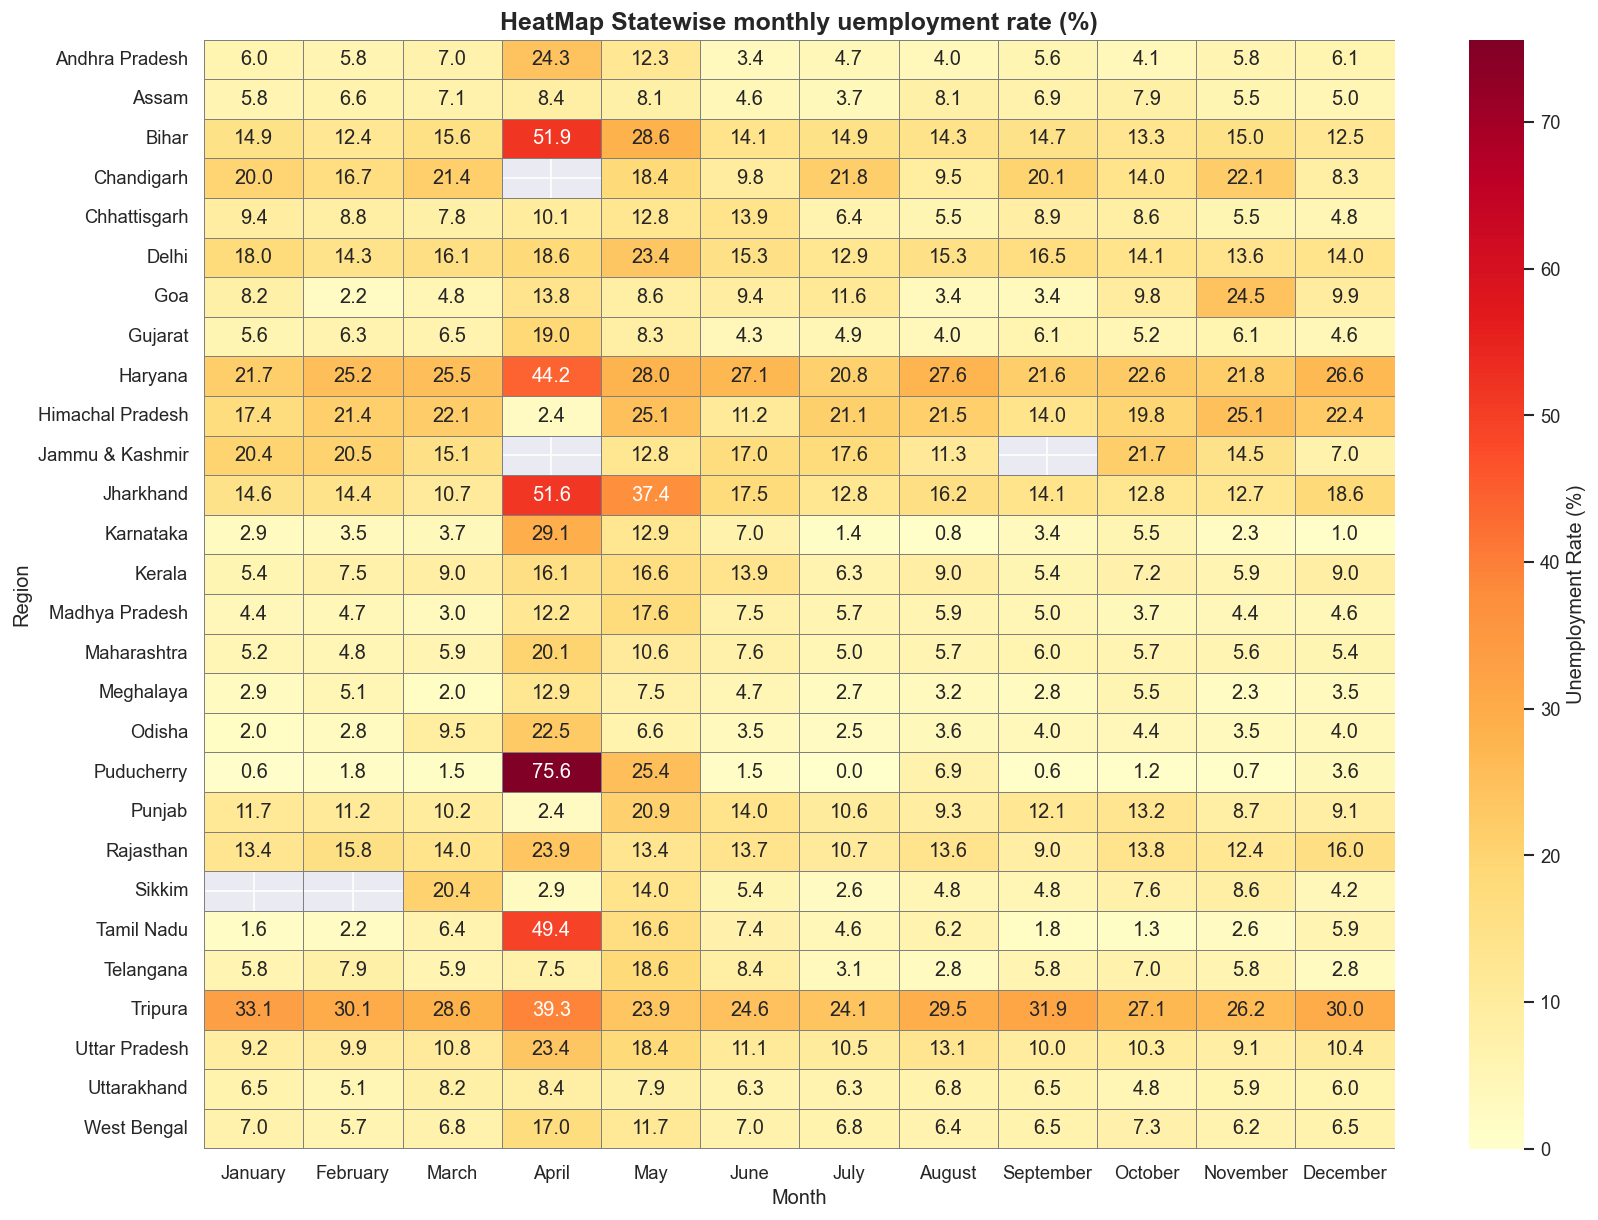

In [30]:
pivot=df1.pivot_table(
    values='Unemployment_Rate',
    index='Region',
    columns='Month',
    aggfunc='mean'
)[month_order]

plt.figure(figsize=(16,12))
sns.heatmap(
    pivot,annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='gray',
    cbar_kws={'label':'Unemployment Rate (%)'}
)
plt.title('HeatMap Statewise monthly uemployment rate (%)',fontsize=15, fontweight='bold')
plt.xlabel()
plt.ylabel('State')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 12 Labour Participation Rate vs Unemployment Rate

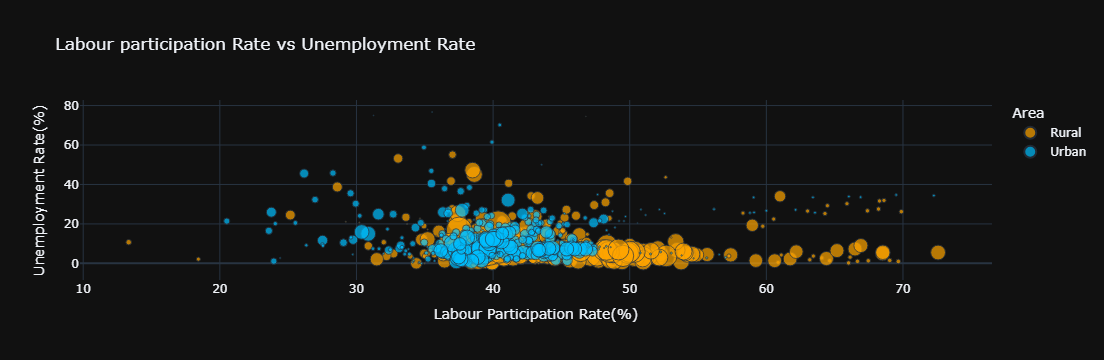

In [36]:
fig=px.scatter(
    df1, x='Labour_Participation_Rate', y='Unemployment_Rate',
    color='Area', size='Employed',
    hover_data=['Region','Date'],
    title='Labour participation Rate vs Unemployment Rate',
    labels={
        'Labour_Participation_Rate':'Labour Participation Rate(%)',
        'Unemployment_Rate':'Unemployment Rate(%)'
    },
    color_discrete_map={'Rural':'#FFA500','Urban':'#00BFFF'},
    opacity=0.7,
    template='plotly_dark'
)
fig.show()

## 13. Correlation Heatmap

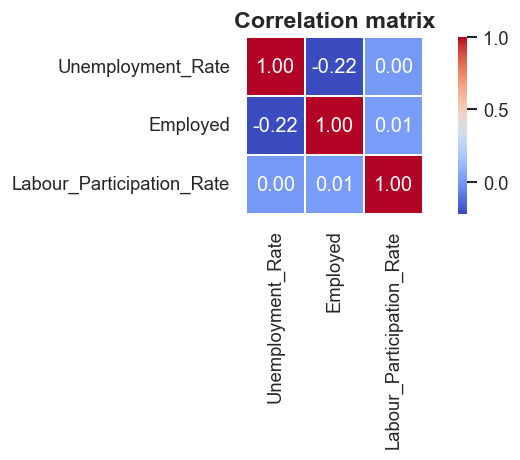

In [38]:
corr=df1[['Unemployment_Rate','Employed','Labour_Participation_Rate']].corr()
plt.figure(figsize=(7,4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=1)
plt.title('Correlation matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 14. Region wise analysis (Dataset-2 Geographic)

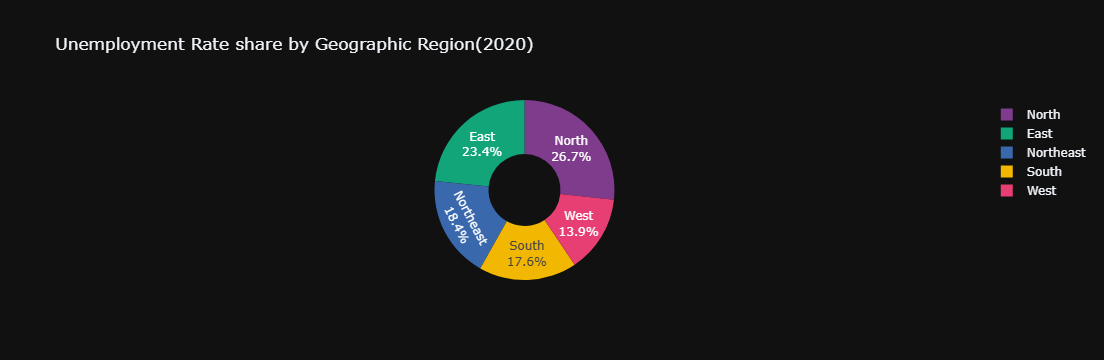

In [41]:
region_avg=df2.groupby('Region')['Unemployment_Rate'].mean().reset_index()

fig=px.pie(
    region_avg, names='Region', values='Unemployment_Rate',
    title='Unemployment Rate share by Geographic Region(2020)',
    color_discrete_sequence=px.colors.qualitative.Bold,
    template='plotly_dark',
    hole=0.4
)
fig.update_traces(textinfo='label+percent')
fig.show()

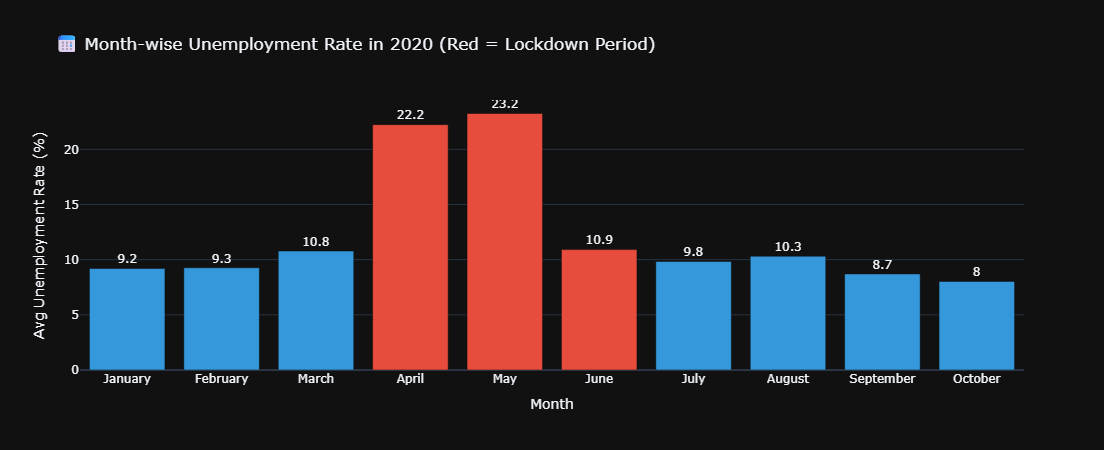

In [43]:
# Month-wise trend within 2020 (Dataset 2)
monthly_2020 = df2.groupby(['Month_num', 'Month'])['Unemployment_Rate'].mean().reset_index().sort_values('Month_num')

fig = go.Figure()
fig.add_trace(go.Bar(
    x=monthly_2020['Month'], y=monthly_2020['Unemployment_Rate'],
    marker_color=['#E74C3C' if m >= 4 and m <= 6 else '#3498DB' for m in monthly_2020['Month_num']],
    text=monthly_2020['Unemployment_Rate'].round(1),
    textposition='outside'
))
fig.update_layout(
    title='📅 Month-wise Unemployment Rate in 2020 (Red = Lockdown Period)',
    xaxis_title='Month', yaxis_title='Avg Unemployment Rate (%)',
    template='plotly_dark', height=450
)
fig.show()

## 15 Statewise Unemployment Map( Scatter Geo)

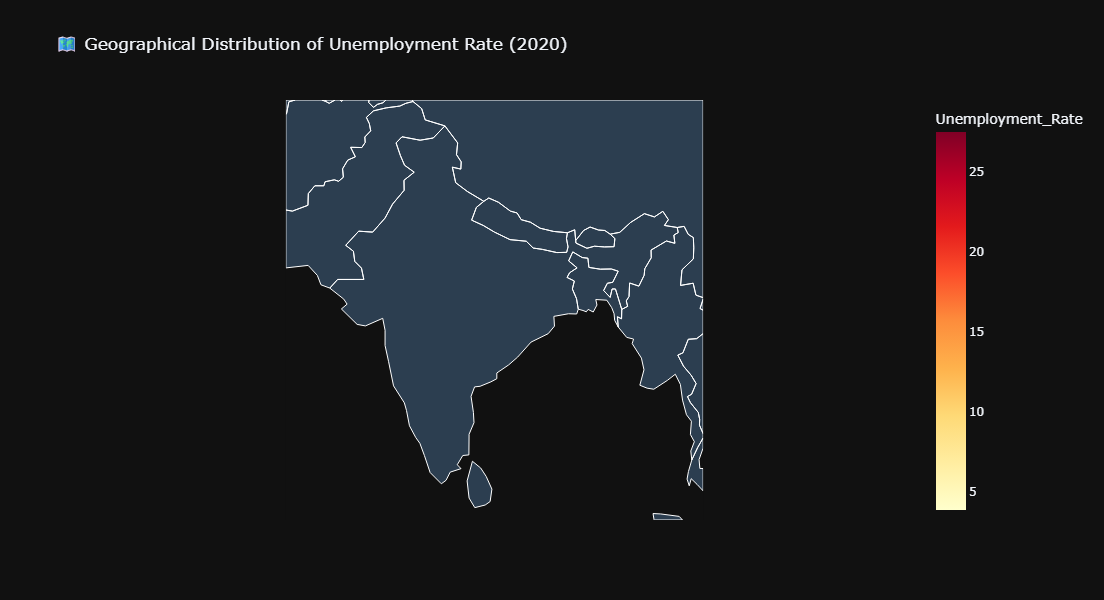

In [46]:
state_geo = df2.groupby(['State', 'Latitude', 'Longitude'])['Unemployment_Rate'].mean().reset_index()

fig = px.scatter_geo(
    state_geo,
    lat='Latitude', lon='Longitude',
    size='Unemployment_Rate',
    color='Unemployment_Rate',
    hover_name='State',
    color_continuous_scale='YlOrRd',
    scope='asia',
    center={'lat': 22, 'lon': 82},
    title='🗺️ Geographical Distribution of Unemployment Rate (2020)',
    template='plotly_dark'
)
fig.update_geos(
    lataxis_range=[6, 38],
    lonaxis_range=[65, 100],
    showland=True, landcolor='#2C3E50',
    showcountries=True, countrycolor='white'
)
fig.update_layout(height=600)
fig.show()

## 16 Sunburst -> Region -> State Unemployment

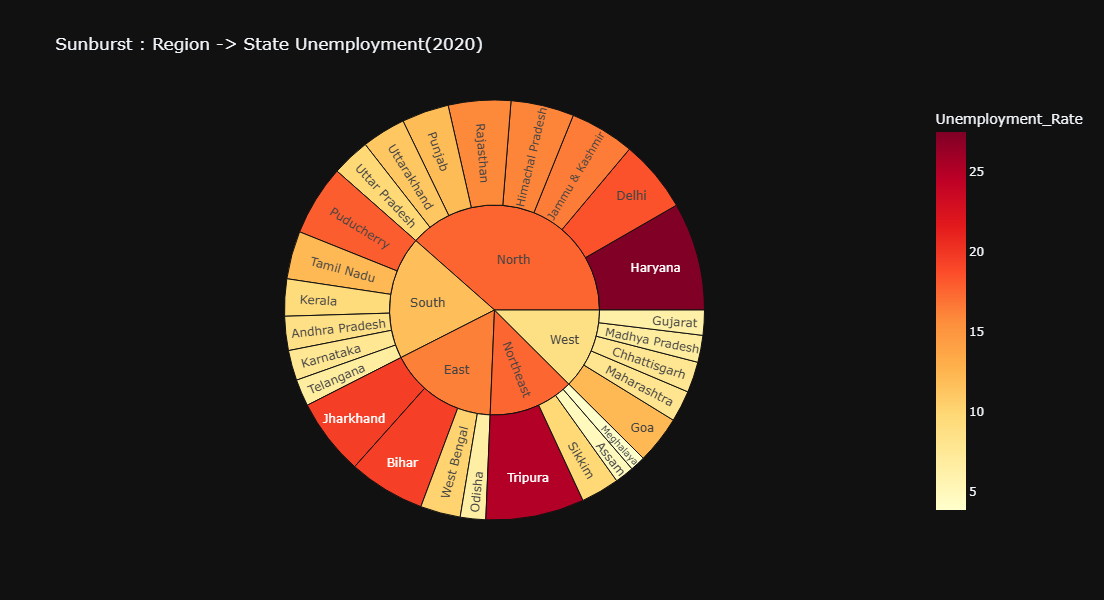

In [48]:
sunburst_data=df2.groupby(['Region','State'])['Unemployment_Rate'].mean().reset_index()
fig=px.sunburst(
    sunburst_data,
    path=['Region','State'],
    values='Unemployment_Rate',
    color='Unemployment_Rate',
    color_continuous_scale='YlOrRd',
    title='Sunburst : Region -> State Unemployment(2020)',
    template='plotly_dark'
)
fig.update_layout(height=600)
fig.show()

---
## 17. Key Insights & Conclusions

```
📌 Key Findings:

1. COVID-19 Impact: India's unemployment rate surged from ~7-8% pre-lockdown
   to over 20-24% in April–May 2020 — the sharpest single-month spike on record.

2. Urban vs Rural: Urban areas consistently showed higher unemployment than
   rural areas, but both spiked sharply during the lockdown period.

3. Most Affected States: States like Jharkhand, Bihar, and Haryana recorded
   the highest average unemployment rates over the study period.

4. Least Affected States: Meghalaya, Odisha, and Gujarat maintained relatively
   lower unemployment rates throughout.

5. Recovery: From July 2020 onwards, unemployment rates began declining,
   suggesting a partial economic recovery as restrictions eased.

6. Labour Participation: There is a mild negative correlation between labour
   participation rate and unemployment — as more people leave the workforce,
   the reported unemployment rate can fall despite economic distress.
```

In [49]:
# Final summary table
summary = pd.DataFrame({
    'Metric': [
        'Overall Avg Unemployment Rate',
        'Pre-Lockdown Avg',
        'Peak Unemployment (Apr 2020)',
        'Avg Labour Participation Rate',
        'State with Highest Avg Unemployment',
        'State with Lowest Avg Unemployment'
    ],
    'Value': [
        f"{df1['Unemployment_Rate'].mean():.2f}%",
        f"{df1[df1['Period']=='Pre-Lockdown']['Unemployment_Rate'].mean():.2f}%",
        f"{df1[df1['Date'].dt.month==4]['Unemployment_Rate'].max():.2f}%",
        f"{df1['Labour_Participation_Rate'].mean():.2f}%",
        state_avg.iloc[0]['Region'] + f" ({state_avg.iloc[0]['Unemployment_Rate']:.2f}%)",
        state_avg.iloc[-1]['Region'] + f" ({state_avg.iloc[-1]['Unemployment_Rate']:.2f}%)"
    ]
})
print('=== 📊 Analysis Summary ===')
summary

=== 📊 Analysis Summary ===


,Metric,Value
0,Overall Avg Unemployment Rate,11.79%
1,Pre-Lockdown Avg,nan%
2,Peak Unemployment (Apr 2020),76.74%
3,Avg Labour Participation Rate,42.63%
4,State with Highest Avg Unemployment,Tripura (28.35%)
5,State with Lowest Avg Unemployment,Meghalaya (4.80%)


---
*End of Notebook — Task 2: Unemployment Analysis with Python*  
**Author:** Dhyan Shah: Data Science Intern | **Dataset Source:** CMIE via Kaggle